In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

On importe les bibliothèques si dessu, si dessous ce trouve les données utilisées

In [4]:
#projection du marché de l'I.A en milliard :
IAmarket=[95.6,142.32,207.9,298.25,420.47,582.95,795.38,1100,1400,1850]
#on se concentre sur les plus gros datacenter, estimation de l'augmentation de la consomation
Consother=2250 #valeur fixe, car les petits datacenter ne bouge pas trop en terme de consomation
Consproj=[3250,3350,3500,3750,3850,4000] #Gigawhat/heure 
Prodcentral=8 #Terrawhat/H
Coupcentral=11 #en milliard
coupcontinuel=64 #euro par mega what
finEU=300 #en million
#en pourcentage
Nuclear=67.1 
Hydro=13.9
Wind=8.7
Sun=4.6
Fossile=3.7
OtherGreen=2

On tente de trouver une échelle logarithmique qui permette d'obtenir une droite :

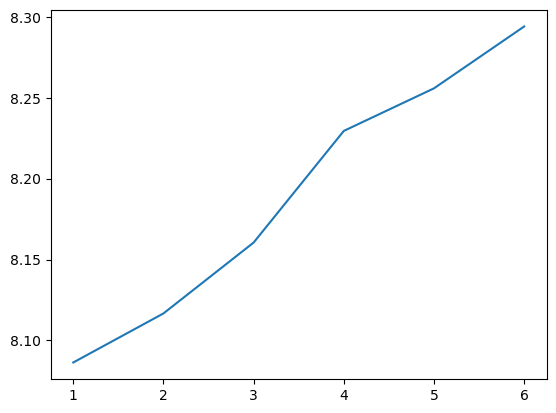

In [5]:
logconso=np.log(Consproj)
index=[1,2,3,4,5,6]
plt.plot(index, logconso)
plt.show()

In [6]:
a, b = np.polyfit(index, logconso, 1)
print(f"Pente a = {a}")
print(f"Ordonnée à l'origine b = {b}")

Pente a = 0.04355794579332404
Ordonnée à l'origine b = 8.038052745384817


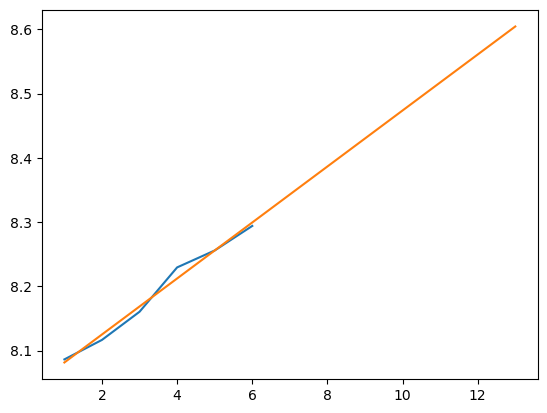

In [7]:
plt.plot(index, logconso)
index=index+[7,8,9,10,11,12,13]
line=[]
for i in index :
    line.append(a*i+b)

plt.plot(index,line)
plt.show()

On réaplique ensuite l'exponentielle pour obtenir la projection :

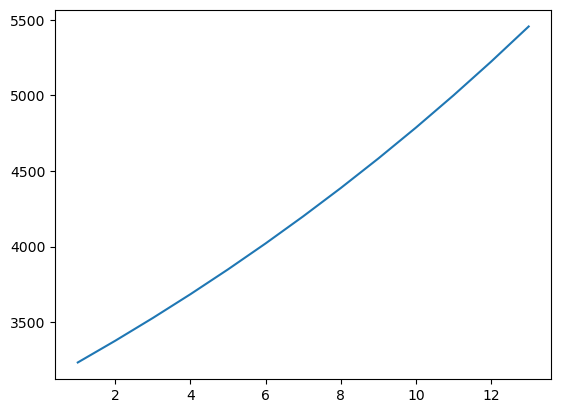

In [8]:
prediction=np.exp(line)
plt.plot(index, prediction)
plt.show()

si dessous le code générant un graphique avec les années, la courbes ainsi que les prédiction :

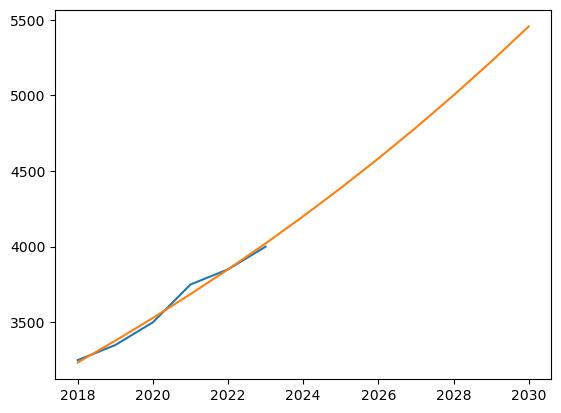

In [9]:
année=[2018,2019,2020,2021,2022,2023]
année2=[2024,2025,2026,2027,2028,2029,2030]
plt.plot(année, Consproj)
plt.plot(année+année2,prediction)
plt.show()


on obtient le graphique final :

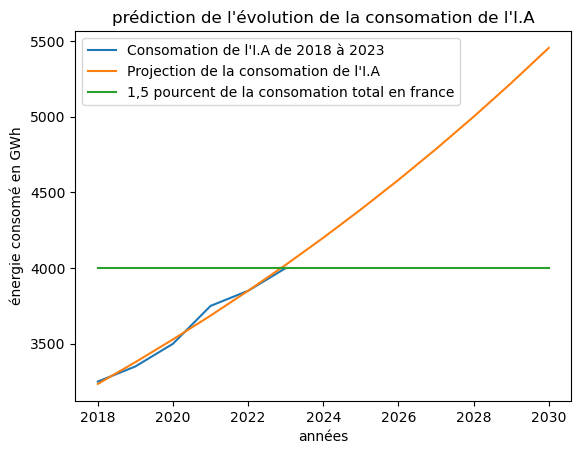

In [10]:
plt.plot(année, Consproj, label="Consomation de l'I.A de 2018 à 2023")
plt.plot(année+année2,prediction, label="Projection de la consomation de l'I.A")
plt.title("prédiction de l'évolution de la consomation de l'I.A")
plt.xlabel('années')
plt.ylabel('énergie consomé en GWh')
onepercent=[]
for i in range(len(année+année2)) :
    onepercent.append(Consproj[-1])
plt.plot(année+année2,onepercent, label="1,5 pourcent de la consomation total en france")
plt.legend()
plt.show()

si dessous le code générant le diagramme fromage sur la production énergétique en france :

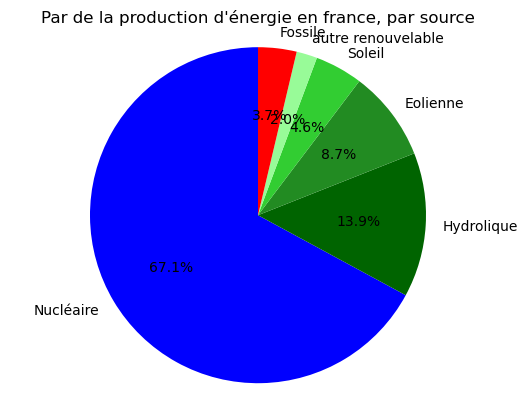

In [11]:
vals=[Nuclear,Hydro,Wind,Sun,OtherGreen,Fossile]
titles=["Nucléaire","Hydrolique","Eolienne","Soleil","autre renouvelable","Fossile"]
Colors=["blue",'#006400','#228B22','#32CD32','#98FB98','red']
plt.pie(vals, labels=titles, colors=Colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title("Par de la production d'énergie en france, par source")
plt.show()

si dessous, le calcul de la prédiction la plus catastrophique possible :

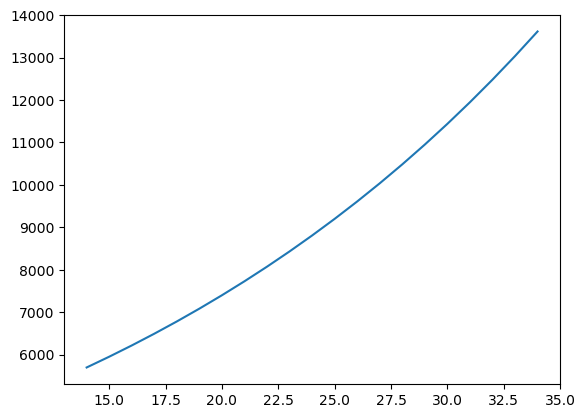

In [12]:
index=[14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34]
pred=[]
for i in index :
    pred.append(math.exp(a*i+b))
plt.plot(index, pred)
plt.show()

On calcul le même scénario mais ette fois si avec des mixture d'expert distribué consomant 3 fois moins :

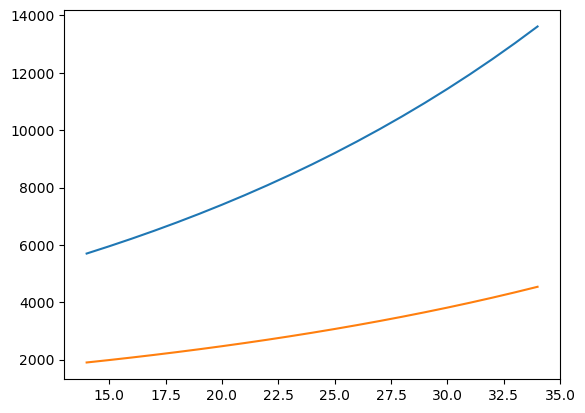

In [13]:
plt.plot(index, pred)
improvedpred=[]
for i in pred :
    improvedpred.append(i/3)
plt.plot(index,improvedpred)
plt.show()

On ne peut pas remplacer tout les LLM par des mixtures d'expert distribué d'un coup, on établie donc un scénario les remplaçant sur une période de 15 ans :

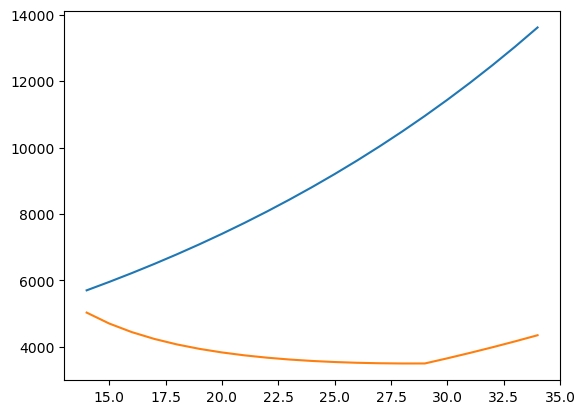

In [16]:
plt.plot(index, pred)
improvedpred=[]
div=1+2/15
for i in pred :
    improvedpred.append(i/div)
    if div<3 :
        div=div+2/15
plt.plot(index, improvedpred)
plt.show()

Le scénario suivant décrit une prédiction ou chaque année, un pourcentage des LLM sont brancher à leur réacteur nucléaire modulaire dédié, les retirants ainsi de la consomation totale du raiseaux. On commence à 10% est on augmente petit à petit, d'2% par ans, chaque année un % plus élevé de LLM est déconecté, pour représenté la progression de la technologie :

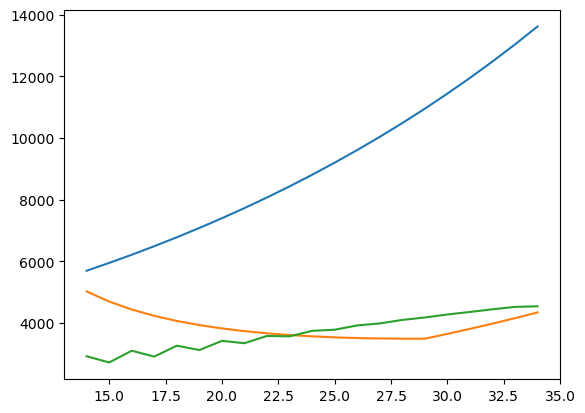

In [31]:
plt.plot(index, pred)
plt.plot(index, improvedpred)
nuclpred=[]
I=0
start=10
for i in pred :
    J=(i-I)
    I=J-((J*start)/100)
    if I>0 :
        nuclpred.append(I)
    else :
        nuclpred.append(0)
    start=start+2
#on lisse la courbe pour évité la dent de scie
for i in range(len(nuclpred)) :
    try :
        nuclpred[i]=(nuclpred[i]+nuclpred[i+1])/2
    except :
        nuclpred[i]=(nuclpred[i]+nuclpred[i-1])/2
plt.plot(index,nuclpred)
plt.show()

On combine les deux scénario :

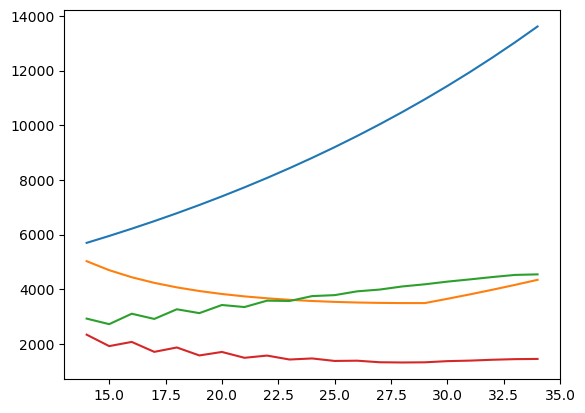

In [32]:
plt.plot(index, pred)
plt.plot(index, improvedpred)
plt.plot(index,nuclpred)
imporvednuclpred=[]
I=0
start=10
for i in improvedpred :
    J=(i-I)
    I=J-((J*start)/100)
    if I>0 :
        imporvednuclpred.append(I)
    else :
        imporvednuclpred.append(0)
    start=start+2
#on lisse la courbe pour évité la dent de scie
for i in range(len(imporvednuclpred)) :
    try :
        imporvednuclpred[i]=(imporvednuclpred[i]+imporvednuclpred[i+1])/2
    except :
        imporvednuclpred[i]=(imporvednuclpred[i]+imporvednuclpred[i-1])/2

plt.plot(index,imporvednuclpred)
plt.show()

graphique final, avec les année, titres et légende :

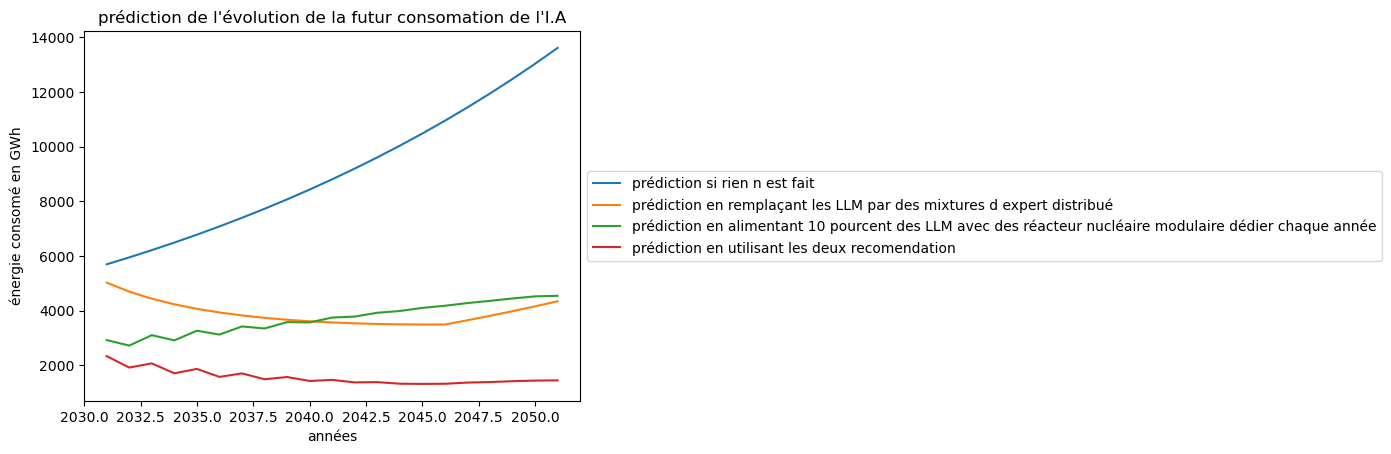

In [33]:
année=[]
year=2031
for i in index :
    année.append(year)
    year=year+1
plt.plot(année, pred,label='prédiction si rien n est fait')
plt.plot(année, improvedpred,label='prédiction en remplaçant les LLM par des mixtures d expert distribué')
plt.plot(année,nuclpred,label='prédiction en alimentant 10 pourcent des LLM avec des réacteur nucléaire modulaire dédier chaque année')
plt.plot(année,imporvednuclpred,label='prédiction en utilisant les deux recomendation')
plt.title("prédiction de l'évolution de la futur consomation de l'I.A")
plt.xlabel('années')
plt.ylabel('énergie consomé en GWh')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


(la légende serra placé en dessous sur la présentation)